Dataset shape: (365299, 6)
Columns: Index(['event', 'timestamp_ns', 'pid', 'comm', 'cpu', 'value'], dtype='object')

Aggregated shape: (67, 5)

Class distribution:
 label
0    34
1    33
Name: count, dtype: int64

Model Performance
Accuracy : 0.9285714285714286
Precision: 1.0
Recall   : 0.8571428571428571
F1 Score : 0.9230769230769231


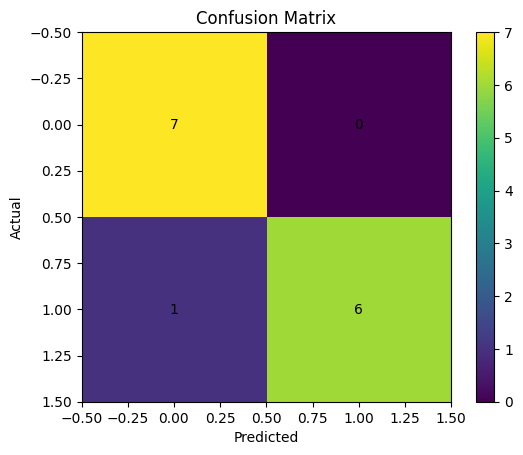

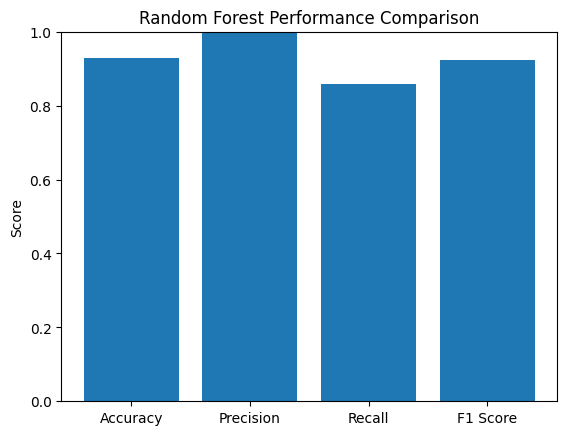

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# -------------------------------------------------
# STEP 1: Load dataset
# -------------------------------------------------
df = pd.read_csv("/content/sched_4F_10seconds.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns)

# -------------------------------------------------
# STEP 2: Aggregate per PID (REALISTIC SCHEDULER VIEW)
# -------------------------------------------------
agg_df = df.groupby("pid").agg(
    total_value=("value", "sum"),
    avg_value=("value", "mean"),
    event_count=("event", "count"),
    cpu_unique=("cpu", "nunique")
).reset_index()

print("\nAggregated shape:", agg_df.shape)

# -------------------------------------------------
# STEP 3: CREATE LABEL (NO LEAKAGE)
# -------------------------------------------------
# Label rule:
# CPU-bound → high runtime (above median)
threshold = agg_df["total_value"].median()

agg_df["label"] = (agg_df["total_value"] > threshold).astype(int)

print("\nClass distribution:\n", agg_df["label"].value_counts())

# -------------------------------------------------
# STEP 4: SPLIT FEATURES & LABEL (REMOVE LEAK SOURCE)
# -------------------------------------------------
X = agg_df.drop(columns=["label", "total_value"])
y = agg_df["label"]

# -------------------------------------------------
# STEP 5: Train-test split (STRICT)
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# STEP 6: Random Forest Model
# -------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# -------------------------------------------------
# STEP 7: Predictions
# -------------------------------------------------
y_pred = rf.predict(X_test)

# -------------------------------------------------
# STEP 8: Metrics
# -------------------------------------------------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\nModel Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# -------------------------------------------------
# STEP 9: Confusion Matrix
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# -------------------------------------------------
# STEP 10: Metric Comparison Graph
# -------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Random Forest Performance Comparison")
plt.ylabel("Score")
plt.show()



kNN Performance
Accuracy : 0.8
Precision: 0.875
Recall   : 0.7
F1 Score : 0.7777777777777778


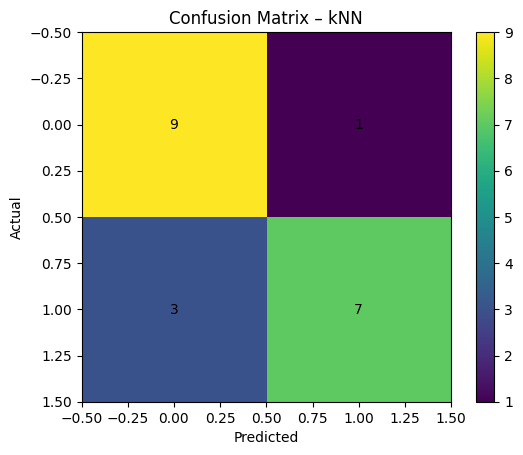

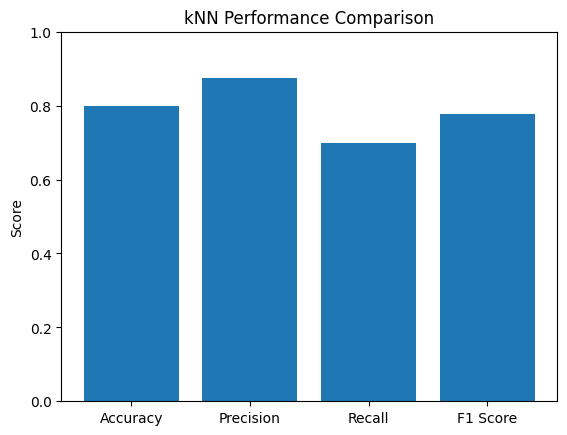

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
df = pd.read_csv("/content/sched_4F_10seconds.csv")

# Aggregate per PID
agg_df = df.groupby("pid").agg(
    total_value=("value", "sum"),
    avg_value=("value", "mean"),
    event_count=("event", "count"),
    cpu_unique=("cpu", "nunique")
).reset_index()

# Label creation
threshold = agg_df["total_value"].median()
agg_df["label"] = (agg_df["total_value"] > threshold).astype(int)

# Features & label
X = agg_df.drop(columns=["label", "total_value"])
y = agg_df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (MANDATORY for kNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# kNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\nkNN Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – kNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

# Metric graph
plt.figure()
plt.bar(["Accuracy", "Precision", "Recall", "F1 Score"],
        [accuracy, precision, recall, f1])
plt.ylim(0, 1)
plt.title("kNN Performance Comparison")
plt.ylabel("Score")
plt.show()



Logistic Regression Performance
Accuracy : 0.6666666666666666
Precision: 0.75
Recall   : 0.5
F1 Score : 0.6


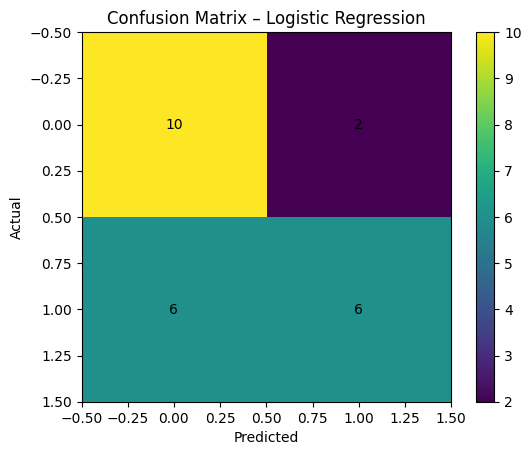

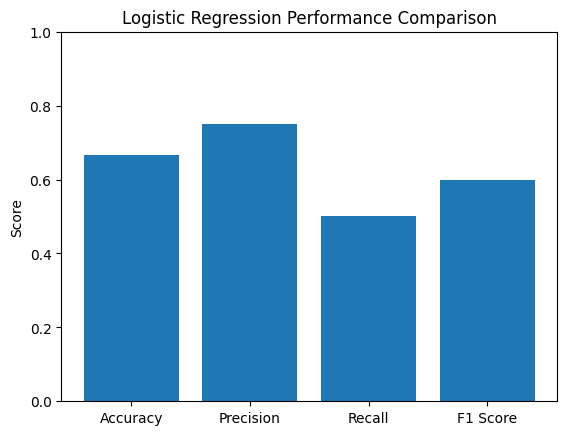

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("/content/sched_4F_10seconds.csv")

agg_df = df.groupby("pid").agg(
    total_value=("value", "sum"),
    avg_value=("value", "mean"),
    event_count=("event", "count"),
    cpu_unique=("cpu", "nunique")
).reset_index()

threshold = agg_df["total_value"].median()
agg_df["label"] = (agg_df["total_value"] > threshold).astype(int)

X = agg_df.drop(columns=["label", "total_value"])
y = agg_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (MANDATORY)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\nLogistic Regression Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

plt.figure()
plt.bar(["Accuracy", "Precision", "Recall", "F1 Score"],
        [accuracy, precision, recall, f1])
plt.ylim(0, 1)
plt.title("Logistic Regression Performance Comparison")
plt.ylabel("Score")
plt.show()



Gradient Boosting Performance
Accuracy : 0.96
Precision: 0.9230769230769231
Recall   : 1.0
F1 Score : 0.96


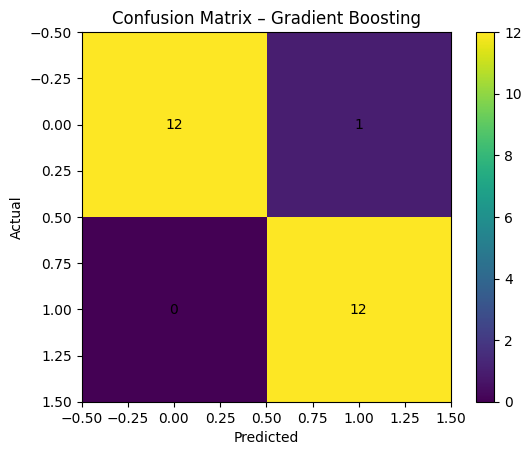

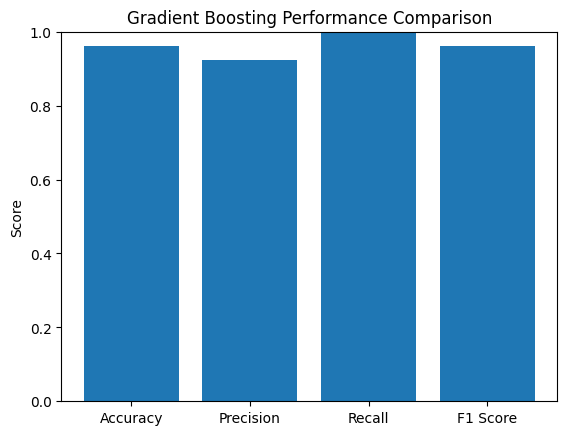

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("/content/sched_4F_10seconds.csv")

agg_df = df.groupby("pid").agg(
    total_value=("value", "sum"),
    avg_value=("value", "mean"),
    event_count=("event", "count"),
    cpu_unique=("cpu", "nunique")
).reset_index()

threshold = agg_df["total_value"].median()
agg_df["label"] = (agg_df["total_value"] > threshold).astype(int)

X = agg_df.drop(columns=["label", "total_value"])
y = agg_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\nGradient Boosting Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

plt.figure()
plt.bar(["Accuracy", "Precision", "Recall", "F1 Score"],
        [accuracy, precision, recall, f1])
plt.ylim(0, 1)
plt.title("Gradient Boosting Performance Comparison")
plt.ylabel("Score")
plt.show()
